# Biomarker discovery with body fluid proteomics (Bader et al, 2020)

## Study background

Below we step through an `alphapepttools` example by using a published dataset by Bader et al. [1], who measured cerebrospinal fluid proteomes in order to discover biomarkers for Alzheimer's disease. 



## Key proteomics methods and considerations

| Challenge | Why It Matters | Our Approach |
|-----------|---------------|--------------|
| **Dynamic range** | Precursors span 6+ orders of magnitude | Log-transform intensities |
| **Missing values** | Proteomics data is ~20-50% missing (MNAR) | We drop features that are less than 75 % complete and apply Perseus-style 'Gaussian' imputation, filling in missing values in each feature from a downshifted normal distribution.
| **Covariates** | Data may contain biologically meaningful covariates (e.g. sex) or technical variability (e.g. well/column on a plate), both of which can partially overlap with the signal of interest (e.g. disease/no disease) | We use `ComBat` as a batch-correction method with an added safety layer: by using Principal Component Regression (PCR), we can quantify how much covariate & disease classification variability was removed during batch correction, ensuring that we don't inadvertantly "smoothe out" variability of interest in an attempt to remove covariate effects.


## References

[1]: Bader, Jakob M., et al. "Proteome profiling in cerebrospinal fluid reveals novel biomarkers of Alzheimer's disease." Molecular systems biology 16.6 (2020): e9356.

[2]: Luecken, M.D., Büttner, M., Chaichoompu, K. et al. Benchmarking atlas-level data integration in single-cell genomics. Nat Methods 19, 41-50 (2022). https://doi.org/10.1038/s41592-021-01336-8

[3]: Büttner, M., Miao, Z., Wolf, F.A. et al. A test metric for assessing single-cell RNA-seq batch correction. Nat Methods 16, 43-49 (2019). https://doi.org/10.1038/s41592-018-0254-1

[4]: Johnson, W. Evan, Cheng Li, and Ariel Rabinovic. "Adjusting batch effects in microarray expression data using empirical Bayes methods." Biostatistics 8.1 (2007): 118-127.

[5]: Stacklies, W., Redestig, H., Scholz, M., Walther, D. & Selbig, J. pcaMethods—a bioconductor package providing PCA methods for incomplete data. Bioinformatics 23, 1164 - 1167 (2007).



## Analysis

In [ ]:
%load_ext autoreload
%autoreload 2

import tempfile
import numpy as np
import pandas as pd

import alphapepttools as apt
import matplotlib.pyplot as plt

### 1. Data loading

#### 1.1. Preparing the dataset using `alphapepttools` loaders and AnnData factory. 

In the case of this study, the full output of the DIANN search is saved as a report file of precursors, from which precursor or protein-level data can be extracted. `alphapepttools` handles this filtering with its AnnData factory class, drawing on the reader functionalities of `alphabase`. The resulting AnnData object contains protein-group quantities and any number of feature-metadata columns (for example, protein groups may have genes as secondary annotation, precursors may have protein groups and genes as secondary annotation).

In [ ]:
output_dir = "./datasets/data_for_02_basic_analysis"
figure_output_dir = "./datasets/data_for_02_basic_analysis/assets"

# Download the dataset using the alphapepttools data module
report_path = apt.data.get_data("bader2020_full_diann", output_dir=tempfile.mkdtemp())
metadata_path = apt.data.get_data("bader2020_metadata", output_dir=tempfile.mkdtemp())

# Create the AnnData object, where the row index corresponds to samples and the column names correspond to proteins
adata_protein = apt.io.read_psm_table(
    file_paths=report_path,
    search_engine="diann",
    level="proteins",
    var_columns=["genes"],  # keep the gene names around
)

# Use the builtin dataframe conversion to get a quick overview of the data
display(adata_protein.to_df().iloc[:5, :5])

/var/folders/17/vmd1w1fd6fq60l0jx7vjsrr40000gn/T/tmpwsnb39lu/report.parquet does not yet exist
/var/folders/17/vmd1w1fd6fq60l0jx7vjsrr40000gn/T/tmpwsnb39lu/report.parquet successfully downloaded (91.135817527771 MB)
/var/folders/17/vmd1w1fd6fq60l0jx7vjsrr40000gn/T/tmpcm4p46sx/annotation of samples_AM1.5.11.xlsx does not yet exist
/var/folders/17/vmd1w1fd6fq60l0jx7vjsrr40000gn/T/tmpcm4p46sx/annotation of samples_AM1.5.11.xlsx successfully downloaded (0.028104782104492188 MB)


proteins,A0A075B6H7,A0A075B6H9,A0A075B6I0,A0A075B6I1,A0A075B6I9
raw_name,,,,,
20180618_QX0_JaBa_SA_LC12_5_CSF1_1_8-1xD1xS1fM1_sampleA01,515756544.0,37080368.0,10454921.0,5.520306e+06,36124044.0
20180618_QX0_JaBa_SA_LC12_5_CSF1_1_8-1xD1xS1fM1_sampleA02,433412480.0,35804032.0,45109720.0,4.065712e+06,45391408.0
20180618_QX0_JaBa_SA_LC12_5_CSF1_1_8-1xD1xS1fM1_sampleA03,262955984.0,32907378.0,10027142.0,1.697559e+06,29789766.0
20180618_QX0_JaBa_SA_LC12_5_CSF1_1_8-1xD1xS1fM1_sampleA04,286271648.0,19701684.0,11276591.0,1.086842e+07,40601508.0
20180618_QX0_JaBa_SA_LC12_5_CSF1_1_8-1xD1xS1fM1_sampleA05,447627040.0,50030340.0,51720148.0,8.910876e+06,117676152.0


#### 1.2. Adding sample metadata

The AnnData format provides a solution to a key problem encountered in every data-analysis project: How to keep a matrix of numerical values permanently and safely aligned with column and row annotations. This is notably difficult with dataframes, as multilevel column indices are cumbersome and non-numeric columns in one dataframe cause problems with downstram analyses methods that expect numerical features. The `add_metadata` function from the preprocessing module ensures alignment of observations and variables from the start.

☝️ Importantly, while the original AnnData implementation only enforces shape compatibility, `alphapepttools.pp.data.apt.pp.add_metadata()` enforces matching indices. This means that even if the initial data and the incoming metadata were to be in different orders, quantitative and metadata information for a given sample are always matched. 

In [ ]:
# Download the metadata using the alphapepttools data module
sample_metadata = pd.read_excel(metadata_path).dropna(subset=["sample name"])

# Basic cleaning of the metadata prior to merging
sample_metadata["sample name"] = sample_metadata["sample name"].str.replace(".raw.PG.Quantity", "", regex=False)
sample_metadata = sample_metadata.set_index("sample name", drop=False)
sample_metadata = sample_metadata.rename(columns={"gender": "sex"})

# The metadata contains information for more samples than are in our data
print(f"AnnData shape: {adata_protein.shape}")
print(f"Metadata shape: {sample_metadata.shape}")

AnnData shape: (61, 2162)
Metadata shape: (210, 14)


In [ ]:
# Match the metadata to the AnnData object
print(f"Anndata shape prior to matching: {adata_protein.shape}")
adata_protein = apt.pp.add_metadata(
    adata=adata_protein,  # The AnnData object we want to add metadata to. Its obs index should match the index of the metadata
    incoming_metadata=sample_metadata,  # The metadata dataframe we want to add. Its index should match the index of adata.obs
    axis=0,  # This means that we add metadata to the rows (0) and not columns (1)
    keep_data_shape=False,  # This means that we will drop any samples for which there is no corresponding row in the metadata
)
print(f"Anndata shape after matching: {adata_protein.shape}")
print()

Anndata shape prior to matching: (61, 2162)
Anndata shape after matching: (61, 2162)



In [ ]:
# Add a "plate_row" column as a Null-covariate for later batch correction evaluation. There is no specific assumption about the plate row in this dataset, other than capturing general variability across the measurement.
adata_protein.obs["plate_row"] = adata_protein.obs.index.str.extract(r"sample([A-H])\d+")[0].to_numpy()
adata_protein = apt.pp.drop_singleton_batches(adata_protein, batch="plate_row")

INFO:alphapepttools.pp.batch_correction: coerce_nans_to_batch: Replacing NaNs in plate_row with 'NA'...
INFO:alphapepttools.pp.batch_correction: coerce_nans_to_batch: Some levels of batch 'plate_row' have only one sample. Dropped samples and their respective value in 'plate_row': [('20180618_QX0_JaBa_SA_LC12_5_CSF1_1_8-1xD1xS1fM1_sampled09', 'NA')]


We can inspect that the metadata was correctly added:

In [ ]:
# From now on, the metadata is stored in adata.obs
print("The sample-level metadata:")
display(adata_protein.obs.head())

# For now, the feature (i.e. protein) metadata is a dataframe with only one column. We could easily add more protein annotations like GO-terms to it
print("The feature-level metadata:")
display(adata_protein.var.head())

# And the protein abundances are stored in adata.X, which is a numpy array and perfectly suited for numerical operations
print("The protein abundances:")
display(adata_protein.X[:5, :5])

The sample-level metadata:


,sample name,collection site,age,sex,t-tau [ng/L],p-tau [ng/L],Abeta-42 [ng/L],Abeta-40 [ng/L],Abeta ratio,biochemical AD classification,clinical AD diagnosis,MMSE score,cohort sample ID,comment,plate_row
raw_name,,,,,,,,,,,,,,,
20180618_QX0_JaBa_SA_LC12_5_CSF1_1_8-1xD1xS1fM1_sampleA01,20180618_QX0_JaBa_SA_LC12_5_CSF1_1_8-1xD1xS1fM...,Sweden,71.0,f,703.0,85.0,562.0,NaN,NaN,biochemical control,NaN,NaN,ID_708,NaN,A
20180618_QX0_JaBa_SA_LC12_5_CSF1_1_8-1xD1xS1fM1_sampleA02,20180618_QX0_JaBa_SA_LC12_5_CSF1_1_8-1xD1xS1fM...,Sweden,77.0,m,518.0,91.0,334.0,NaN,NaN,biochemical AD,NaN,NaN,ID_722,NaN,A
20180618_QX0_JaBa_SA_LC12_5_CSF1_1_8-1xD1xS1fM1_sampleA03,20180618_QX0_JaBa_SA_LC12_5_CSF1_1_8-1xD1xS1fM...,Sweden,75.0,m,974.0,87.0,515.0,NaN,NaN,biochemical AD,NaN,NaN,ID_734,NaN,A
20180618_QX0_JaBa_SA_LC12_5_CSF1_1_8-1xD1xS1fM1_sampleA04,20180618_QX0_JaBa_SA_LC12_5_CSF1_1_8-1xD1xS1fM...,Sweden,72.0,f,950.0,109.0,394.0,NaN,NaN,biochemical AD,NaN,NaN,ID_742,NaN,A
20180618_QX0_JaBa_SA_LC12_5_CSF1_1_8-1xD1xS1fM1_sampleA05,20180618_QX0_JaBa_SA_LC12_5_CSF1_1_8-1xD1xS1fM...,Sweden,63.0,f,873.0,88.0,234.0,NaN,NaN,biochemical AD,NaN,NaN,ID_757,NaN,A


The feature-level metadata:


,genes
proteins,
A0A075B6H7,IGKV3-7
A0A075B6H9,IGLV4-69
A0A075B6I0,IGLV8-61
A0A075B6I1,IGLV4-60
A0A075B6I9,IGLV7-46


The protein abundances:


array([[5.1575654e+08, 3.7080368e+07, 1.0454921e+07, 5.5203060e+06,
        3.6124044e+07],
       [4.3341248e+08, 3.5804032e+07, 4.5109720e+07, 4.0657125e+06,
        4.5391408e+07],
       [2.6295598e+08, 3.2907378e+07, 1.0027142e+07, 1.6975589e+06,
        2.9789766e+07],
       [2.8627165e+08, 1.9701684e+07, 1.1276591e+07, 1.0868422e+07,
        4.0601508e+07],
       [4.4762704e+08, 5.0030340e+07, 5.1720148e+07, 8.9108760e+06,
        1.1767615e+08]], dtype=float32)

#### 1.3. Using `alphapepttools` to generate an overview of the metadata

In order to understand the properties of our data, we may want to generate overviews of certain columns in the metadata. To quickly generate publication-grade visuals, we utilize `alphapepttools.pl` and its asssociated functionalities. 

An example of `apt.pl.create_figure`'s iterative subplotting feature starts with specifying a number of numerical features we want to visualize:

In [ ]:
# Check distribution of age and other numerical columns
numerical_columns = ["age", "t-tau [ng/L]", "p-tau [ng/L]", "Abeta-42 [ng/L]"]

In [ ]:
# Assign a distinct color to each of our columns
palette = apt.pl.BasePalettes.get("qualitative", n=len(numerical_columns))

# Save the combination of numerical column and color in a dictionary
numerical_metadata_color_dict = dict(zip(numerical_columns, palette, strict=False))

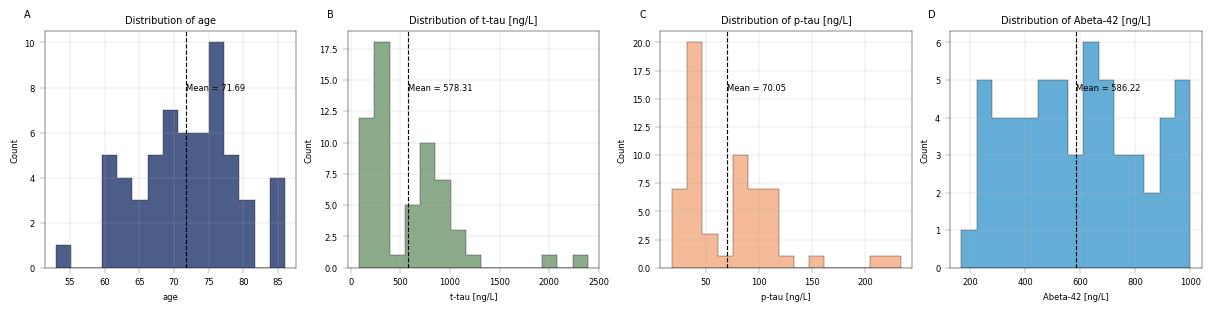

In [ ]:
fig, axm = apt.pl.create_figure(1, len(numerical_columns), figsize=(3 * len(numerical_columns), 3))

# Iterate over the columns and generate the histograms.
# Note that we also iterate over a string of letters to label the individual subplots with A, B, C, ...
for col, enumeration in zip(numerical_columns, "ABCDEFGHIJKLMNOP", strict=False):
    ax = axm.next()  # Go to the next facette of the AxesManager

    # Plot the histogram for the current column
    apt.pl.histogram(
        ax=ax,
        bins=15,
        data=adata_protein,
        value_column=col,
        color=numerical_metadata_color_dict[col],
        # Add whatever flourish we want for the histograms
        hist_kwargs={
            "histtype": "stepfilled",
            "alpha": 0.7,
            "edgecolor": "black",
        },
    )

    # Label the individual axes (note that this takes the Axes object as an argument, so
    # everything gets layered onto the same figure)
    apt.pl.label_axes(
        ax=ax,
        xlabel=col,
        ylabel="Count",
        title=f"Distribution of {col}",
        enumeration=enumeration,
    )

    # Indicate means with a vertical line
    mean = adata_protein.obs[col].mean()  # calculate the mean of the current column in the metadata
    apt.pl.add_lines(
        ax=ax,
        intercepts=mean,
        linetype="vline",
        color="black",
    )

    # Add a label for each mean
    apt.pl.label_plot(
        ax=ax,
        data=pd.DataFrame({"x": [mean], "y": [0.75], "label": [f"Mean = {mean:.2f}"]}),
        x_column="x",
        y_column="y",
        label_column="label",
        # The code is necessary to position all mean labels at the same height.
        # It essentially means "Use data coordinates for the x-axis, but use axes coordinates (0-1) for the y-axis".
        label_kwargs={"transform": ax.get_xaxis_transform()},
    )

    # Since the figure size is fixed from the initial generation of the subplot, we can save it looking exactly as we see below in the notebook
    apt.pl.save_figure(
        fig=fig,  # Note that here we're using the whole figure to whose axes we added our plots
        filename="continuous_var_overview.svg",
        output_dir="./example_outputs",
    )

☝️ A particular painpoint for many analyses is that the same *levels* should ideally have the same color throughout the entire analysis (i.e. it can be confusing if "disease" is colored red in one plot and green in the next). This can be annoyingly subtle to get right, which is why `alphapepttools` plots support a *color_dict* we can create upfront. This way, the same level is colored uniformly across all our plots.

Next, we instantiate a multi-panel figure with one facet for each of our numerical columns. A figure like this could be used for a supplementary figure, where the distribution of relevant columns should be shown.

#### 1.3. Log2-transformation of proteomics data

When running `alphapepttools.pp`'s `nanlog()` We get a warning that our data contains NaN values, which are ignored in the log-transform.
When verbosity is set to 1, `nanlog()` alerts to special values for which log-transformation is not possible.

In [ ]:
# First, move the original data to a new layer called "raw" to preserve it before log transformation
adata_protein.layers["raw"] = adata_protein.X.copy()

apt.pp.nanlog(adata_protein, base=2, verbosity=1)

### 2. Perform QC and EDA on protein data

We would like a small panel to highlight the distribution of our protein intensities with highlights the 10 most abundant proteins, and look at the protein distribution across all our samples to check if we need imputation.

In [ ]:
# consistent coloring for disease status
ad_color_dict = {
    "biochemical control": apt.pl.BaseColors.get("yellow"),
    "biochemical AD": apt.pl.BaseColors.get("purple"),
}

#### 2.1. Check key metrics in the data:

Before commencing to further analyses, it is recommended to check very basic parameters of measured samples, namely

- The total summed intensity in each sample
- The total number of detected features in each sample 

There should be no surprises here - we expect both quantities to be approximately constant across the range of measured samples, unless there is a prior reason to expect fewer features in one or a group of samples (e.g. in pulldowns with varying affinity). 
For the study at hand we expect a relatively flat profile of these QC metrics.

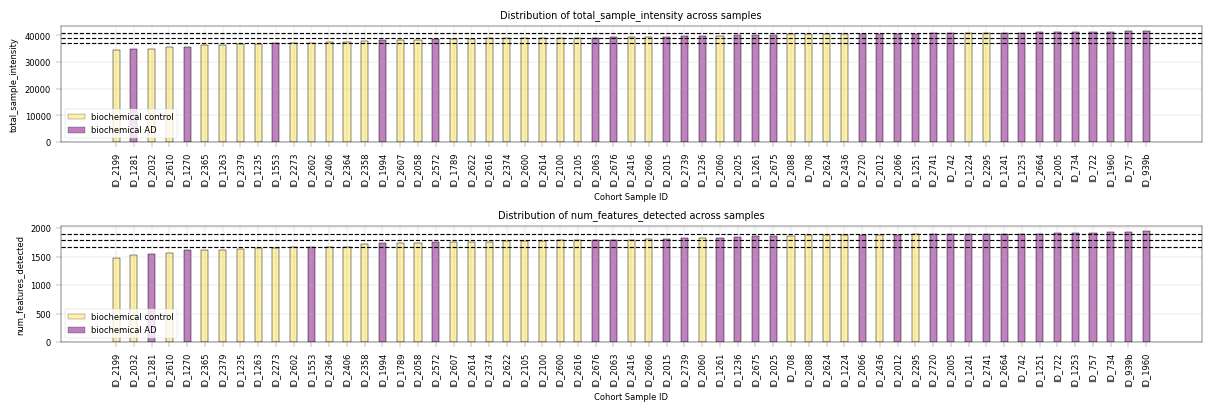

In [ ]:
# Run QC-metrics calculation on the AnnData object & visualize
apt.metrics.calculate_qc_metrics(adata_protein)

# Assign samples to their colors based on the treatment group: make an array of colors that corresponds to the samples and save the result in a sample-level coloring dict
qc_sample_level_color_dict = {}
for sample_id, status in zip(
    adata_protein.obs["cohort sample ID"], adata_protein.obs["biochemical AD classification"], strict=False
):
    qc_sample_level_color_dict[sample_id] = ad_color_dict.get(status, apt.pl.BaseColors.get("gray"))

# Barplots for QC metrics
fig, axm = apt.pl.create_figure(2, 1, figsize=(12, 4))
for metric in ["total_sample_intensity", "num_features_detected"]:
    ax = axm.next()

    apt.pl.barplot(
        ax=ax,
        data=adata_protein.obs.sort_values(metric),
        grouping_column="cohort sample ID",
        value_column=metric,
        color_dict=qc_sample_level_color_dict,
    )

    # rotate x labels for better readability
    ax.set_xticklabels(ax.get_xticklabels(), rotation=90, ha="center")

    apt.pl.label_axes(
        ax=ax,
        xlabel="Cohort Sample ID",
        ylabel=metric,
        title=f"Distribution of {metric} across samples",
    )

    apt.pl.add_legend_to_axes(
        ax=ax,
        levels=ad_color_dict,
        alpha=0.5,
    )

    # Average and stdev of the metric
    mean = adata_protein.obs[metric].mean()  # calculate the mean of the current column in the metadata
    std = adata_protein.obs[metric].std()  # calculate the standard deviation of the current column in the metadata
    apt.pl.add_lines(
        ax=ax,
        intercepts=[mean, mean + std, mean - std],
        linetype="hline",
    )

**Observation** 

We see that on average, AD samples seem to be somewhat enriched in the higher intensity/feature count region, though the difference still remains small with most samples landing within one standard deviation of the mean (black lines).

**Conclusion**

Minor differences in the feature count appear to be present, but overall samples are highly homogenous and we proceed with analysis.



#### 2.2. Check biological QCs in the data

Aside from purely technoligical validations, whether underlying biological expectations are met can help validate the dataset as a whole. For this, we can check the distribution of protein abundances across the dynamic range. 
We expect the most abundant proteins to be *Albumin* and other plasma-derived factors, along with canonical CSF proteins like *Prealbumin*.

In [ ]:
# getting the median abundance of each protein across all samples
adata_protein.var["median_abundance"] = np.nanmedian(adata_protein.X, axis=0)
adata_protein.var["rank"] = adata_protein.var["median_abundance"].rank(ascending=False)

# get medians for the top 5 proteins with the highest median abundance
top_10_protein_medians = adata_protein.var.nlargest(10, "median_abundance")
top_10_indices = top_10_protein_medians.index

# get medians for some specific proteins of interest (hemoglobins)
hemoglobin_genes = ["HBA1", "HBB", "HBD", "HBE1"]
hemoglobin_medians = adata_protein.var.loc[adata_protein.var["genes"].isin(hemoglobin_genes), :]
hemoglobin_indices = hemoglobin_medians.index

# Concatenate the two series into a single DataFrame for labelling
poi_median_df = pd.concat([top_10_protein_medians, hemoglobin_medians])

# Mark the proteins in the dataframe for coloring
adata_protein.var["status"] = "other"
adata_protein.var.loc[top_10_indices, "status"] = "top_10"
adata_protein.var.loc[hemoglobin_indices, "status"] = "hemoglobin"

# Set up a coloring scheme for the proteins of interest (poi) and other proteins
rank_color_dict = {
    "top_10": apt.pl.BaseColors.get("green"),
    "hemoglobin": apt.pl.BaseColors.get("red"),
    "other": apt.pl.BaseColors.get("lightgrey"),
}

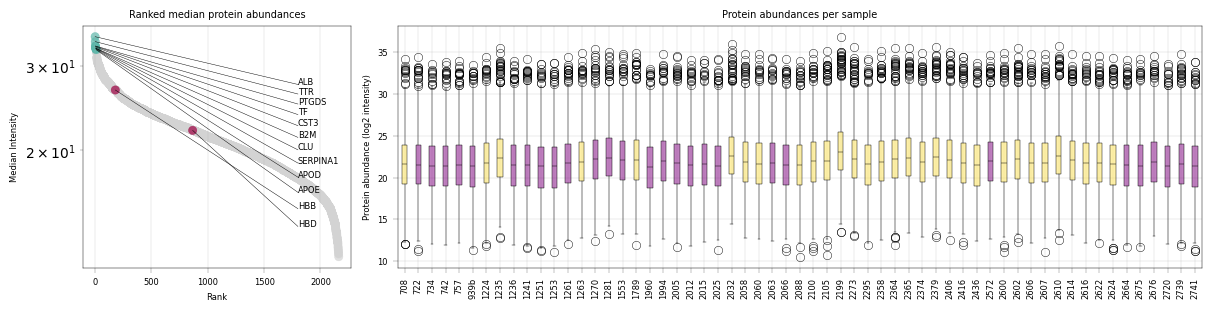

In [ ]:
# Generate a panel to contain the rank plot and the protein abundance boxplots
fig, axm = apt.pl.create_figure(1, 2, figsize=(12, 3), gridspec_kwargs={"width_ratios": [1, 3]})

# First, show the protein values
ax = axm.next()
apt.pl.rank_median_plot(
    data=adata_protein,
    ax=ax,
    color_map_column="status",  # The column to indicate which proteins are special
    color_dict=rank_color_dict,  # How to color the special proteins
    scatter_kwargs={
        "alpha": 0.7,
    },
)

apt.pl.label_axes(
    ax=ax,
    title="Ranked median protein abundances",
)

apt.pl.label_plot(
    ax=ax,
    data=poi_median_df,
    x_column="rank",
    y_column="median_abundance",
    label_column="genes",
    x_anchors=[1800],
    y_display_start=0.9,
    y_padding_factor=4,
)


# Next, show the protein intensity per sample
ax = axm.next()
boxplot_df = adata_protein.T.to_df()  # Convert the AnnData object to a DataFrame for plotting
boxplot_df.columns = adata_protein.obs["cohort sample ID"]  # Use the cohort sample ID as column names for the boxplot
apt.pl.boxplot(
    ax=ax,
    data=boxplot_df,
    direct_columns=boxplot_df.columns.tolist(),
    color_dict=qc_sample_level_color_dict,
)

# The ax object is always accessible, so a little matplotlib code can get rid of
# cumbersome long xtick labels:
xtick_labels = [item.get_text() for item in ax.get_xticklabels()]  # Get xtick labels directly from axes
xtick_labels = [x.split("_")[-1] for x in xtick_labels]  # Shorten the xtick labels to make them more readable
_ = ax.set_xticklabels(xtick_labels, rotation=90)  # Set the new xtick labels

apt.pl.label_axes(
    ax=ax,
    title="Protein abundances per sample",
    ylabel="Protein abundance (log2 intensity)",
)

# Save the figure
apt.pl.save_figure(
    fig=fig,  # Note that here we're using the whole figure to whose axes we added our plots
    filename="protein_abundance_overview.png",
    output_dir="./example_outputs",
)

**Observation**

We see the expected sigmoid-like distribution of protein median abundances, with proteins like *Albumin* (ALB) and *Prealbumin* (TF) as well as *Apolipoproteins D and E* (APOD, APOE) showing up in the top 10 as expected. Beyond that, we again see that features are consistently distributed across samples.

**Conclusion**

Data matches the expected apprearance of LC-MS CSF measurements. The presence of hemoglobin contaminants indicates that attention should be paid to whether a potential biomarker clusters with contaminants or not (see main publication[1] for further details).

#### 2.3. Filter proteins based on their completeness across samples

In [ ]:
# We restrict our dataset to proteins with no more than 25 % missing values across all samples
adata_25pc = adata_protein.copy()
adata_25pc = apt.pp.filter_data_completeness(
    adata=adata_25pc,
    max_missing=0.25,
    action="drop",
)

INFO:root:pp.filter_data_completeness(): drop 527 / 2162 features with >0.25 missing.


#### 2.4. Generate PCA clustering of data, colored by different variables

PCA values are computed and saved to the same AnnData instance, making use of its `obsm`, `varm`, and `uns` (unstructured) data fields.

In [ ]:
ge_color_dict = {
    "m": apt.pl.BasePalettes.get("qualitative")[7],
    "f": apt.pl.BasePalettes.get("qualitative")[6],
}

In [ ]:
# We impute the remaining missing values from a downshifted gaussian distribution
adata_25pc = adata_25pc.transpose()
apt.pp.impute_gaussian(
    adata=adata_25pc,
)
adata_25pc = adata_25pc.transpose()

# Add PCA embeddings to the AnnData object by utilizing its 'obsm' attribute
apt.tl.pca(adata_25pc, n_comps=10)

# Locating the PCA results
print("\nPCA Components: adata.obsm['X_pca'] with shape (n_obs x n_comps):")
print(adata_25pc.obsm["X_pca_obs"].shape)

print("\nPCA loadings: adata.varm['PCs'] with shape (n_var x n_comps):")
print(adata_25pc.varm["PCs_pca_obs"].shape)

print("\nRatio of explained variance: uns['pca']['variance_ratio'] with shape (n_comps,):")
print(adata_25pc.uns["variance_pca_obs"]["variance_ratio"])

print("\nExplained variance: uns['pca']['variance'] with shape (n_comps):")
print(adata_25pc.uns["variance_pca_obs"]["variance"])

INFO:alphapepttools.tl.embeddings:computing PCA



PCA Components: adata.obsm['X_pca'] with shape (n_obs x n_comps):
(60, 10)

PCA loadings: adata.varm['PCs'] with shape (n_var x n_comps):
(1635, 10)

Ratio of explained variance: uns['pca']['variance_ratio'] with shape (n_comps,):
[0.21584404 0.06609076 0.04943129 0.03917123 0.03749295 0.03278059
 0.03061898 0.02667243 0.02359037 0.02286303]

Explained variance: uns['pca']['variance'] with shape (n_comps):
[225.29024   68.983154  51.5946    40.885525  39.133793  34.215202
  31.958986  27.839725  24.622786  23.863607]


#### 2.5. Examine PCA with respect to Alzheimer's classification


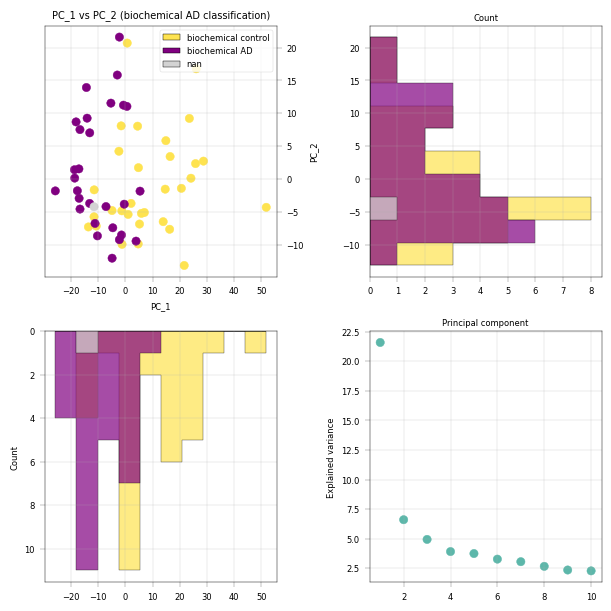

In [ ]:
# Visualizing the PCA results
fig, axm = apt.pl.create_figure(2, 2, figsize=(6, 6))

# We can get the PCA component values into a dataframe
pca_df = pd.DataFrame(
    adata_25pc.obsm["X_pca_obs"],
    index=adata_25pc.obs.index,
    columns=[f"PC_{i + 1}" for i in range(adata_25pc.obsm["X_pca_obs"].shape[1])],
)
pca_df = pca_df.join(adata_25pc.obs)

# Color by biochemical AD classification
ax = axm.next()
apt.pl.scatter(
    ax=ax,
    data=pca_df,
    x_column="PC_1",
    y_column="PC_2",
    color_map_column="biochemical AD classification",
    legend="auto",
    color_dict=ad_color_dict,
)
apt.pl.label_axes(
    ax=ax,
    xlabel="PC_1",
    ylabel="PC_2",
    title="PC_1 vs PC_2 (biochemical AD classification)",
)
# Move the y-axis label to the right side of the plot
ax.yaxis.set_label_position("right")
ax.yaxis.tick_right()

# Go on and add 90 degree tilted histograms for the second component
ax = axm.next()
apt.pl.histogram(
    ax=ax,
    data=pca_df,
    value_column="PC_2",
    color_map_column="biochemical AD classification",
    hist_kwargs={
        "histtype": "stepfilled",
        "alpha": 0.7,
        "edgecolor": "black",
        "orientation": "horizontal",
    },
    color_dict=ad_color_dict,
)
apt.pl.label_axes(
    ax=ax,
    xlabel="Count",
)
ax.xaxis.set_label_position("top")

# Add a histogram for the first component
ax = axm.next()
apt.pl.histogram(
    ax=ax,
    data=pca_df,
    value_column="PC_1",
    color_map_column="biochemical AD classification",
    hist_kwargs={
        "histtype": "stepfilled",
        "alpha": 0.7,
        "edgecolor": "black",
    },
    color_dict=ad_color_dict,
)
apt.pl.label_axes(
    ax=ax,
    ylabel="Count",
)
ax.invert_yaxis()

# And lastly a scree plot to show the explained varince
ax = axm.next()
apt.pl.scree_plot(
    ax=ax,
    adata=adata_25pc,
    n_pcs=10,
    color=apt.pl.BaseColors.get("green"),
)
apt.pl.label_axes(
    ax=ax,
    xlabel="Principal component",
    ylabel="Explained variance",
)
ax.xaxis.set_label_position("top")

#### 2.6. Examine PCA with respect to the biological covariate "sex"


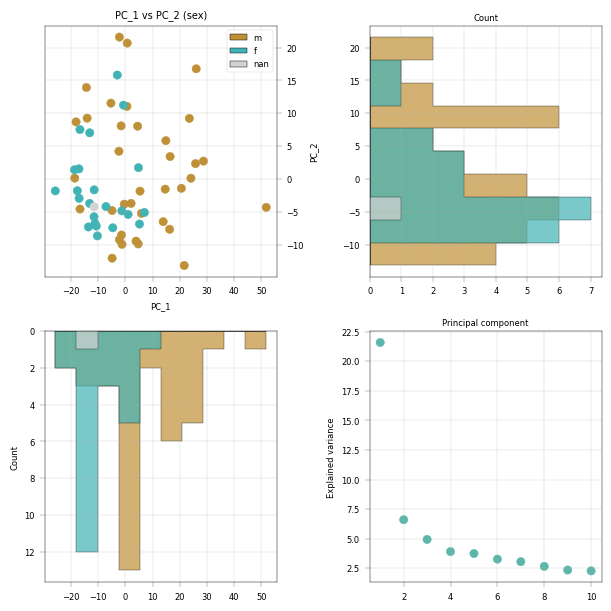

In [ ]:
# Visualizing the PCA results
fig, axm = apt.pl.create_figure(2, 2, figsize=(6, 6))

# We can get the PCA component values into a dataframe
pca_df = pd.DataFrame(
    adata_25pc.obsm["X_pca_obs"],
    index=adata_25pc.obs.index,
    columns=[f"PC_{i + 1}" for i in range(adata_25pc.obsm["X_pca_obs"].shape[1])],
)
pca_df = pca_df.join(adata_25pc.obs)

# Color by biochemical AD classification
ax = axm.next()
apt.pl.scatter(
    ax=ax,
    data=pca_df,
    x_column="PC_1",
    y_column="PC_2",
    color_map_column="sex",
    legend="auto",
    color_dict=ge_color_dict,
)
apt.pl.label_axes(
    ax=ax,
    xlabel="PC_1",
    ylabel="PC_2",
    title="PC_1 vs PC_2 (sex)",
)
# Move the y-axis label to the right side of the plot
ax.yaxis.set_label_position("right")
ax.yaxis.tick_right()

# Go on and add 90 degree tilted histograms for the second component
ax = axm.next()
apt.pl.histogram(
    ax=ax,
    data=pca_df,
    value_column="PC_2",
    color_map_column="sex",
    hist_kwargs={
        "histtype": "stepfilled",
        "alpha": 0.7,
        "edgecolor": "black",
        "orientation": "horizontal",
    },
    color_dict=ge_color_dict,
)
apt.pl.label_axes(
    ax=ax,
    xlabel="Count",
)
ax.xaxis.set_label_position("top")

# Add a histogram for the first component
ax = axm.next()
apt.pl.histogram(
    ax=ax,
    data=pca_df,
    value_column="PC_1",
    color_map_column="sex",
    hist_kwargs={
        "histtype": "stepfilled",
        "alpha": 0.7,
        "edgecolor": "black",
    },
    color_dict=ge_color_dict,
)
apt.pl.label_axes(
    ax=ax,
    ylabel="Count",
)
ax.invert_yaxis()

# And lastly a scree plot to show the explained varince
ax = axm.next()
apt.pl.scree_plot(
    ax=ax,
    adata=adata_25pc,
    n_pcs=10,
    color=apt.pl.BaseColors.get("green"),
)
apt.pl.label_axes(
    ax=ax,
    xlabel="Principal component",
    ylabel="Explained variance",
)
ax.xaxis.set_label_position("top")

**Critical observation**

It appears that both AD-classification and the covariate "sex" show separation in component 1. Correcting for the latter may remove variance associated with our primary disease classification, making this tradeoff a key metric to consider before committing to batch correction.

### 3. Batch correction

A simple and effective way of correcting for batch effects was published under the name ComBat [4]. Based on Empirical Bayes methods, it can remove technical or sampling batch effects while retaining biological information. 

The function implementation has two major failure modes which causes batch correction to fail: A) If a batch occurs exactly once or B) if there are NaN-values in the data. We can check for both and mitigate them:

In [ ]:
adata_25pc = apt.pp.drop_singleton_batches(adata_25pc, batch="sex")

INFO:alphapepttools.pp.batch_correction: coerce_nans_to_batch: Replacing NaNs in sex with 'NA'...
INFO:alphapepttools.pp.batch_correction: coerce_nans_to_batch: Some levels of batch 'sex' have only one sample. Dropped samples and their respective value in 'sex': [('20180618_QX0_JaBa_SA_LC12_5_CSF1_1_8-1xD1xS1fM1_sampleB10R1', 'NA')]


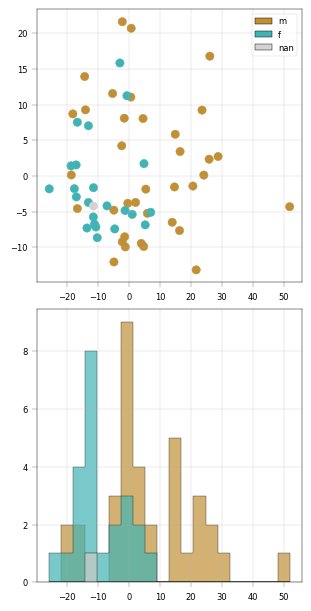

In [ ]:
# visualize the data before batch correction
fig, axm = apt.pl.create_figure(2, 1, figsize=(3, 6))
apt.pl.scatter(
    ax=axm.next(),
    data=pca_df,
    x_column="PC_1",
    y_column="PC_2",
    color_map_column="sex",
    color_dict=ge_color_dict,
    legend="auto",
)
apt.pl.histogram(
    ax=axm.next(),
    data=pca_df,
    value_column="PC_1",
    bins=20,
    color_map_column="sex",
    hist_kwargs={
        "histtype": "stepfilled",
        "alpha": 0.7,
        "edgecolor": "black",
    },
    color_dict=ge_color_dict,
)

In [ ]:
# Apply PyCombat batch correction
adata_25pc_corr = adata_25pc.copy()
apt.pp.scanpy_pycombat(
    adata=adata_25pc_corr,
    batch="sex",
)

INFO:alphapepttools.pp.batch_correction: scanpy_pycombat: pply pyComBat to correct for sex
... storing 'collection site' as categorical
... storing 'sex' as categorical
... storing 'biochemical AD classification' as categorical
... storing 'plate_row' as categorical
... storing 'genes' as categorical
... storing 'status' as categorical


INFO:alphapepttools.tl.embeddings:computing PCA


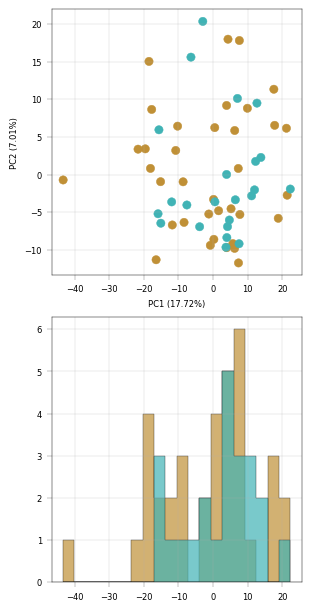

In [ ]:
# recompute pca TODO: Remove dataframe based plotting for pca_plot or adapter down the line
apt.tl.pca(adata_25pc_corr, n_comps=10)
pca_df_corr = pd.DataFrame(
    adata_25pc_corr.obsm["X_pca_obs"],
    index=adata_25pc_corr.obs.index,
    columns=[f"PC_{i + 1}" for i in range(adata_25pc_corr.obsm["X_pca_obs"].shape[1])],
)
pca_df_corr = pca_df_corr.join(adata_25pc_corr.obs)

# Visualize again
fig, axm = apt.pl.create_figure(2, 1, figsize=(3, 6))
apt.pl.plot_pca(
    ax=axm.next(), data=adata_25pc_corr, x_column=1, y_column=2, color_map_column="sex", color_dict=ge_color_dict
)
apt.pl.histogram(
    ax=axm.next(),
    data=pca_df_corr,
    value_column="PC_1",
    bins=20,
    color_map_column="sex",
    hist_kwargs={
        "histtype": "stepfilled",
        "alpha": 0.7,
        "edgecolor": "black",
    },
    color_dict=ge_color_dict,
)

### 4. Quantifying the effects of batch correction

As we have seen above, batch correction is very useful to remove separation by a confounding variable (e.g. 'sex'), but blindly applying batch correction risks overcorrecting the data and removing diagnostic variability. As soon as diagnostic and confounding variablity are not 100 % orthogonal, removing the latter takes away from the former's power to separate data. One key consideration in proteomics data analysi is the question "*how do we know that our batch correction didn't make things worse by removing too much variability?*". The `alphapepttools.metrics.principal_component_regression` ("PCR") module provides a quantitative answer to this problem:

**PCR** quantifies how much of the variation in your data is explained by a specific factor (e.g., batch or disease). Think of it as a way to measure how strongly a particular variable influences the overall structure of your dataset.

The method operates in three steps. First, for each principal component (PC), it calculates the correlation between that PC and your factor of interest. Second, it weights this correlation by the amount of total variance that PC explains in the dataset. Finally, it sums these weighted correlations across all PCs to produce a single metric. 

When PCR is close to 0, it indicates that the factor has little influence on the overall data structure. Conversely, values approaching 1 suggest that the factor strongly drives the main patterns in your data. In the context of batch correction assessment, you expect to see high PCR values for batch effects before correction, indicating that technical variation dominates the data structure. After successful correction, the PCR for batch should drop substantially, although there is also no universal threshold for what constitutes "acceptable" batch effects. Meanwhile, the PCR for biological factors should remain stable or even increase, confirming that the biological signal has been preserved.

There are some caveats when using principal component regression. The method assumes linear relationships between factors and PCs, which means it may miss complex, non-linear batch effects. For more info, checkout the original publications that suggested the metric for the assessment of batch effects in (single cell RNAseq) omics data. 

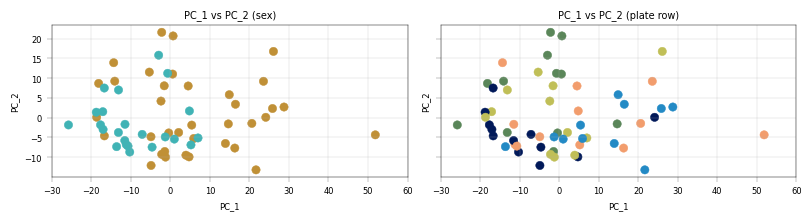

In [ ]:
# Visualizing the PCA results without batch correction
fig, axm = apt.pl.create_figure(1, 2, figsize=(8, 4), subplots_kwargs={"sharex": True, "sharey": True})

# We can get the PCA component values into a dataframe
pca_df = pd.DataFrame(
    adata_25pc.obsm["X_pca_obs"],
    index=adata_25pc.obs.index,
    columns=[f"PC_{i + 1}" for i in range(adata_25pc.obsm["X_pca_obs"].shape[1])],
)
pca_df = pca_df.join(adata_25pc.obs)

# Panel 1: Color by sex
ax = axm.next()
apt.pl.scatter(
    ax=ax,
    data=pca_df,
    x_column="PC_1",
    y_column="PC_2",
    color_map_column="sex",
    color_dict=ge_color_dict,
    xlim=(-30, 50),
)
apt.pl.label_axes(
    ax=ax,
    xlabel="PC_1",
    ylabel="PC_2",
    title="PC_1 vs PC_2 (sex)",
)

# ensure equal aspect ratio for the scatter plot
ax.set_aspect("equal", adjustable="box")

# x ticks every 10 marks spanning the range of PC_1
pc1_min = pca_df["PC_1"].min()
pc1_max = pca_df["PC_1"].max()
ax.set_xticks(np.arange(np.floor(pc1_min / 10) * 10, np.ceil(pc1_max / 10) * 10 + 5, 10))

# Panel 2: Color by plate row
ax = axm.next()
apt.pl.scatter(
    ax=ax,
    data=pca_df,
    x_column="PC_1",
    y_column="PC_2",
    color_map_column="plate_row",
    xlim=(-30, 50),
)
apt.pl.label_axes(
    ax=ax,
    xlabel="PC_1",
    ylabel="PC_2",
    title="PC_1 vs PC_2 (plate row)",
)
# ensure equal aspect ratio for the scatter plot
ax.set_aspect("equal", adjustable="box")

# x ticks every 10 marks spanning the range of PC_1
pc1_min = pca_df["PC_1"].min()
pc1_max = pca_df["PC_1"].max()
ax.set_xticks(np.arange(np.floor(pc1_min / 10) * 10, np.ceil(pc1_max / 10) * 10 + 5, 10))

plt.show()

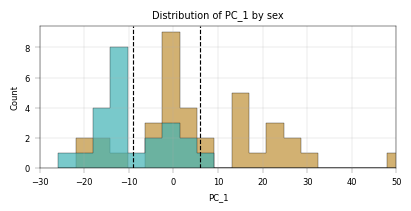

In [ ]:
# small histogram for PC_1's distribution by sex
fig, axm = apt.pl.create_figure(1, 1, figsize=(4, 2))
ax = axm.next()

apt.pl.histogram(
    ax=ax,
    data=pca_df,
    value_column="PC_1",
    color_map_column="sex",
    color_dict=ge_color_dict,
    bins=20,
    hist_kwargs={
        "histtype": "stepfilled",
        "alpha": 0.7,
        "edgecolor": "black",
    },
    xlim=(-30, 50),
)

# vertical lines for means
pc1_df = pca_df[["PC_1", "sex"]].copy()
means = pc1_df.groupby("sex")["PC_1"].mean().to_list()

apt.pl.add_lines(
    ax=ax,
    intercepts=means,
    linetype="vline",
)

apt.pl.label_axes(
    ax=ax,
    xlabel="PC_1",
    ylabel="Count",
    title="Distribution of PC_1 by sex",
)

INFO:alphapepttools.pp.batch_correction: scanpy_pycombat: pply pyComBat to correct for sex
... storing 'collection site' as categorical
... storing 'sex' as categorical
... storing 'biochemical AD classification' as categorical
... storing 'plate_row' as categorical


... storing 'genes' as categorical
... storing 'status' as categorical
INFO:alphapepttools.tl.embeddings:computing PCA
INFO:alphapepttools.pp.batch_correction: scanpy_pycombat: pply pyComBat to correct for plate_row
... storing 'collection site' as categorical
... storing 'sex' as categorical
... storing 'biochemical AD classification' as categorical
... storing 'plate_row' as categorical
... storing 'genes' as categorical
... storing 'status' as categorical
INFO:alphapepttools.tl.embeddings:computing PCA


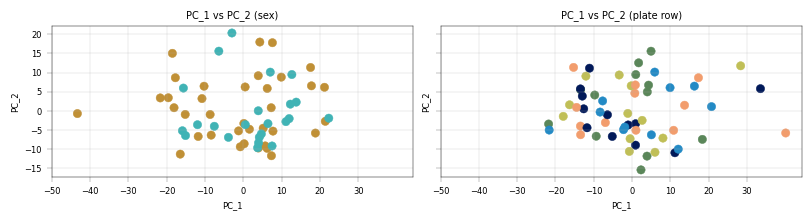

In [ ]:
# Visualizing the PCA results with batch correction: left panel corrects for sex, right panel corrects for well

# Apply PyCombat batch correction for sex
adata_25pc_corr_sex = adata_25pc.copy()
apt.pp.scanpy_pycombat(
    adata=adata_25pc_corr_sex,
    batch="sex",
)
apt.tl.pca(adata_25pc_corr_sex, n_comps=10)

# Apply PyCombat batch correction for plate row
adata_25pc_corr_plate_row = adata_25pc.copy()
apt.pp.scanpy_pycombat(
    adata=adata_25pc_corr_plate_row,
    batch="plate_row",
)
apt.tl.pca(adata_25pc_corr_plate_row, n_comps=10)

# Visualizing the PCA results without batch correction
fig, axm = apt.pl.create_figure(1, 2, figsize=(8, 4), subplots_kwargs={"sharex": True, "sharey": True})

# Panel 1: Batch-corrected and colored by sex
pca_df_corr_sex = pd.DataFrame(
    adata_25pc_corr_sex.obsm["X_pca_obs"],
    index=adata_25pc_corr_sex.obs.index,
    columns=[f"PC_{i + 1}" for i in range(adata_25pc_corr_sex.obsm["X_pca_obs"].shape[1])],
)
pca_df_corr_sex = pca_df_corr_sex.join(adata_25pc_corr_sex.obs)

ax = axm.next()
apt.pl.scatter(
    ax=ax,
    data=pca_df_corr_sex,
    x_column="PC_1",
    y_column="PC_2",
    color_map_column="sex",
    color_dict=ge_color_dict,
)
apt.pl.label_axes(
    ax=ax,
    xlabel="PC_1",
    ylabel="PC_2",
    title="PC_1 vs PC_2 (sex)",
)

# ensure equal aspect ratio for the scatter plot
ax.set_aspect("equal", adjustable="box")

# x ticks every 10 marks spanning the range of PC_1
pc1_min = pca_df_corr_sex["PC_1"].min()
pc1_max = pca_df_corr_sex["PC_1"].max()
ax.set_xticks(np.arange(np.floor(pc1_min / 10) * 10, np.ceil(pc1_max / 10) * 10 + 5, 10))

# Panel 2: Batch-corrected and colored by plate row
pca_df_corr_plate_row = pd.DataFrame(
    adata_25pc_corr_plate_row.obsm["X_pca_obs"],
    index=adata_25pc_corr_plate_row.obs.index,
    columns=[f"PC_{i + 1}" for i in range(adata_25pc_corr_plate_row.obsm["X_pca_obs"].shape[1])],
)
pca_df_corr_plate_row = pca_df_corr_plate_row.join(adata_25pc_corr_plate_row.obs)

ax = axm.next()
apt.pl.scatter(
    ax=ax,
    data=pca_df_corr_plate_row,
    x_column="PC_1",
    y_column="PC_2",
    color_map_column="plate_row",
)
apt.pl.label_axes(
    ax=ax,
    xlabel="PC_1",
    ylabel="PC_2",
    title="PC_1 vs PC_2 (plate row)",
)


# ensure equal aspect ratio for the scatter plot
ax.set_aspect("equal", adjustable="box")

# x ticks every 10 marks spanning the range of PC_1
pc1_min = pca_df_corr_sex["PC_1"].min()
pc1_max = pca_df_corr_sex["PC_1"].max()
ax.set_xticks(np.arange(np.floor(pc1_min / 10) * 10, np.ceil(pc1_max / 10) * 10 + 5, 10))

plt.show()

  means = pc1_df.groupby("sex")["PC_1"].mean().to_list()



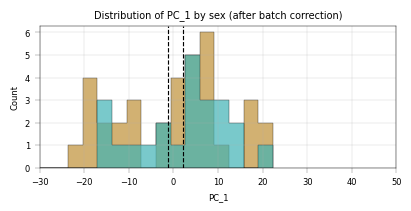

In [ ]:
# small histogram for corrected PC_1's distribution by sex

fig, axm = apt.pl.create_figure(1, 1, figsize=(4, 2))
ax = axm.next()

apt.pl.histogram(
    ax=ax,
    data=pca_df_corr_sex,
    value_column="PC_1",
    color_map_column="sex",
    color_dict=ge_color_dict,
    bins=20,
    hist_kwargs={
        "histtype": "stepfilled",
        "alpha": 0.7,
        "edgecolor": "black",
    },
    xlim=(-30, 50),
)

# vertical lines for means
pc1_df = pca_df_corr_sex[["PC_1", "sex"]].copy()
means = pc1_df.groupby("sex")["PC_1"].mean().to_list()

apt.pl.add_lines(
    ax=ax,
    intercepts=means,
    linetype="vline",
)

apt.pl.label_axes(
    ax=ax,
    xlabel="PC_1",
    ylabel="Count",
    title="Distribution of PC_1 by sex (after batch correction)",
)

#### 4.1. Principal component regression 

Running PCR on 'sex' and 'plate_row' along with 'biochemical AD classification' for both `pca_df_corr_sex` and `pca_df_corr_plate_row`. The key insight is that PCR allows us to get an estimate of our variance of interest (i.e. Biochemical AD classification), and our biological (sex) and technical (plate row) covariates. 

In an ideal scenario, batch correction for a covariate would completely abrogate separation by the covariate, and leave the variance of interest unchanged. In practice, variances are rarely 100 % orthogonal, and any correction usually comes at a cost of losing overall signal. --> PCR puts numbers to this tradeoff, making batch correction an informed cost vs. benefit decision.

In [ ]:
# get three colors from the diverging scale
variance_color_palette = apt.pl.BaseColormaps.get("diverging")([0.0, 0.5, 1.0])

variance_color_dict = {
    "biochemical AD classification": variance_color_palette[0],
    "sex": variance_color_palette[1],
    "plate_row": variance_color_palette[2],
}

  elif pd.api.types.is_categorical_dtype(y):

  elif pd.api.types.is_categorical_dtype(y):

  elif pd.api.types.is_categorical_dtype(y):

  elif pd.api.types.is_categorical_dtype(y):

  elif pd.api.types.is_categorical_dtype(y):

  elif pd.api.types.is_categorical_dtype(y):

  elif pd.api.types.is_categorical_dtype(y):

  elif pd.api.types.is_categorical_dtype(y):



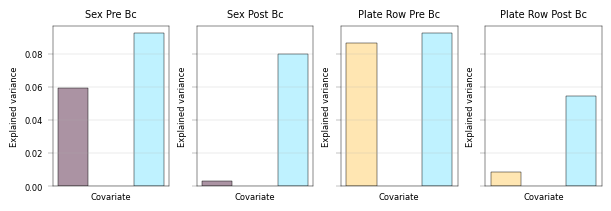

In [ ]:
# Ensure compatible datatypes in corrected & uncorrected data
for a in (adata_25pc, adata_25pc_corr_sex, adata_25pc_corr_plate_row):
    for col in ["sex", "plate_row", "biochemical AD classification"]:
        a.obs[col] = a.obs[col].astype("category")

pcr_cols_sex = ["sex", "biochemical AD classification"]
pcr_cols_plate_row = ["plate_row", "biochemical AD classification"]

collected_variances = {}

# AD classification variance without batch correction
variances_sex = {}
for pcr_col in pcr_cols_sex:
    variances_sex[pcr_col] = apt.metrics.principal_component_regression(
        adata_25pc, covariate=pcr_col, pca_key="X_pca_obs", pca_key_uns="variance_pca_obs"
    )
collected_variances["sex_pre_bc"] = variances_sex

# AD classification variance with batch correction for sex
variances_bc_sex = {}
for pcr_col in pcr_cols_sex:
    variances_bc_sex[pcr_col] = apt.metrics.principal_component_regression(
        adata_25pc_corr_sex, covariate=pcr_col, pca_key="X_pca_obs", pca_key_uns="variance_pca_obs"
    )
collected_variances["sex_post_bc"] = variances_bc_sex

# AD classification variance without batch correction
variances_plate_row = {}
for pcr_col in pcr_cols_plate_row:
    variances_plate_row[pcr_col] = apt.metrics.principal_component_regression(
        adata_25pc, covariate=pcr_col, pca_key="X_pca_obs", pca_key_uns="variance_pca_obs"
    )
collected_variances["plate_row_pre_bc"] = variances_plate_row

# AD classification variance with batch correction for plate row
variances_bc_plate_row = {}
for pcr_col in pcr_cols_plate_row:
    variances_bc_plate_row[pcr_col] = apt.metrics.principal_component_regression(
        adata_25pc_corr_plate_row, covariate=pcr_col, pca_key="X_pca_obs", pca_key_uns="variance_pca_obs"
    )
collected_variances["plate_row_post_bc"] = variances_bc_plate_row

# Visualize results as barplots
fig, axm = apt.pl.create_figure(1, 4, figsize=(6, 2), subplots_kwargs={"sharey": True})

for _i, (key, variances) in enumerate(collected_variances.items()):
    ax = axm.next()

    # data to dataframe
    plot_columns = ["covariate", "explained_variance"]
    plot_df = pd.DataFrame(
        [(covariate, explained_variance) for covariate, explained_variance in variances.items()], columns=plot_columns
    )

    apt.pl.barplot(
        ax=ax,
        data=plot_df,
        grouping_column="covariate",
        value_column="explained_variance",
        color_dict=variance_color_dict,
    )
    apt.pl.label_axes(
        ax=ax,
        xlabel="Covariate",
        ylabel="Explained variance",
        title=key.replace("_", " ").title(),
    )

    # drop x ticks
    ax.set_xticks([])

### 5. Differential expression analysis of the Sweden cohort (DIA-NN)

This demo notebook is restricted to the "Sweden" cohort of the original study. In the next section we aim to recapitulate the original study's differential expression analysis ([1], Figure 2, A). Instead of the original Perseus implementation, we use the `alphapepttools.tl.diff_exp_ebayes` function for differential expression. 

In [ ]:
# # Recapitulate the data ingestion but focus on the gene level
# adata_genes = apt.io.read_psm_table(
#     file_paths=report_path,
#     search_engine="diann",
#     level="genes",
# )
# adata_genes = apt.pp.add_metadata(
#     adata=adata_genes,
#     incoming_metadata=sample_metadata,
#     axis=0,
#     keep_data_shape=False,
# )
# apt.pp.nanlog(adata=adata_genes)

# # Remove samples with no AD classification
# adata_genes = adata_genes[~adata_genes.obs["biochemical AD classification"].isna(), :]

# # Fix name in the data matrix
# adata_genes.obs["biochemical AD classification"] = adata_genes.obs["biochemical AD classification"].str.replace(
#     " ", "_", regex=False
# )

# # Filter for 75 % data completeness and impute with KNN
# adata_genes = apt.pp.filter_data_completeness(
#     adata=adata_genes,
#     max_missing=0.25,
#     action="drop",
# )

# # Impute the remaining missing values using KNN imputation
# adata_genes = apt.pp.impute_gaussian(adata=adata_genes, n_neighbors=5, copy=True)

From the publication, the genes MAPT (Tau protein) and YWHAG (14-3-3c protein) are selected as proteins of interest

In [ ]:
# remove spaces from contrast names
adata_25pc.obs["biochemical AD classification"] = adata_25pc.obs["biochemical AD classification"].str.replace(
    " ", "_", regex=False
)

# Differential expression using the empirial Bayes t-test
comparison, de_results = apt.tl.diff_exp_ebayes(
    adata=adata_25pc,
    between_column="biochemical AD classification",
    comparison=("biochemical_AD", "biochemical_control"),
)

# transfer gene annotation from var to results
de_results = de_results.join(adata_25pc.var[["genes"]], how="left")

INFO:alphapepttools.tl.diff_exp.ebayes:Running Limma eBayes differential expression analysis via inmoose
INFO:alphapepttools.tl.diff_exp.ebayes:Comparing levels: biochemical_AD (treatment) vs biochemical_control (control)
INFO:alphapepttools.tl.utils:Number of samples for biochemical_AD: 28
INFO:alphapepttools.tl.utils:Number of samples for biochemical_control: 31
INFO:root:pp.filter_data_completeness(): drop 0 / 1635 features with >0.00 missing.
INFO:alphapepttools.tl.diff_exp.ebayes:Computing contrast: condition[biochemical_AD]-condition[biochemical_control]
INFO:alphapepttools.tl.diff_exp.ebayes:Design matrix dimensions: 59 samples x 2 groups
INFO:alphapepttools.tl.diff_exp.ebayes:Expression matrix dimensions: 1635 proteins x 59 samples


In [ ]:
# Annotate regulation status without explicit fc cutoff
fc_cutoff = 0
pvalue_cutoff = 0.05
de_results["status"] = "nonregulated"
de_results.loc[(de_results["fdr"] < pvalue_cutoff) & (de_results["log2fc"] < -fc_cutoff), "status"] = "downregulated"
de_results.loc[(de_results["fdr"] < pvalue_cutoff) & (de_results["log2fc"] > fc_cutoff), "status"] = "upregulated"

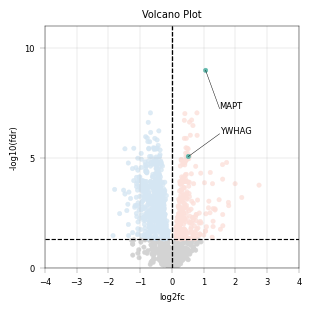

In [ ]:
# Select genes of interest
pois = ["MAPT", "YWHAG"]

# Specify the colors to use
color_dict = {
    "upregulated": apt.pl.BaseColors.get("orange", alpha=0.8, lighten=0.8),
    "downregulated": apt.pl.BaseColors.get("blue", alpha=0.8, lighten=0.8),
    "nonregulated": apt.pl.BaseColors.get("lightgrey"),
    "poi": apt.pl.BaseColors.get("green"),
}

# Specify volcano plot layers: tuples of (column_name, value, color_key) to use for coloring the points in the volcano plot.
layers = [
    ("genes", pois, "poi"),
    ("status", "upregulated", "upregulated"),
    ("status", "downregulated", "downregulated"),
    ("status", "nonregulated", "nonregulated"),
]

# fig, axm = apt.pl.create_figure(1, 1, figsize=(1.8, 1))
fig, axm = apt.pl.create_figure(1, 1, figsize=(3, 3))
ax = axm.next()


apt.pl.volcano(
    ax=ax,
    data=de_results,
    x_column="log2fc",
    y_column="-log10(fdr)",
    layers=layers,
    color_dict=color_dict,
    x_thresholds=(-fc_cutoff, fc_cutoff),
    label_layers=["poi"],
    display_id_column="genes",
    x_label_anchors=[1.5],
    y_display_start=0.8,
    scatter_kwargs={"s": 10},
    ylims=(0, 11),
)

# Add y-ticks every 5 units
ax.set_yticks(np.arange(0, 12, 5))

# Add x-ticks every 1 unit
ax.set_xticks(np.arange(-4, 5, 1))

# Save figure
apt.pl.save_figure(
    fig=fig,
    filename="volcano_plot.png",
    output_dir="./example_outputs",
    dpi=600,
    transparent=True,
)

plt.show()

## Summary

In summary, using `alphapepttools` we...

- could swiftly load & standardize PSM-level search engine results into protein-level `AnnData` instances
- annotated `AnnData` with metadata tables
- performed basic exploratory data analysis (EDA) and created suitable visuals to communicte data properties
- performed advanced EDA using batch correction (ComBat)
- assessed the effects of batch correction on variate and covariate variability within the dataset, informing the decision of whether or not to batch-correct.